# ED wait times - create wait time base heuristic

We will create a base heuristic to compare our model against. We will create a smooth 24 hour wait time curve for each of the two EDs for each day (i.e., 7 curves per ED). Those curves can be used to approximate wait times (albeit independent of queue size).

## Read in dataset csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.interpolate import make_interp_spline

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df1 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/wic_wait_times_20241029211500_20250228191630.csv')

## Initial transformations

Filter the dataset to just the emergency departments.


Cast the datetime and create a new column for day of week.

In [3]:
df = df1.copy()
df = df[(df['id']=='NORHOSED') | (df['id']=='CBRHOSED')].reset_index(drop=True)
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'])
df['day_of_week'] = df['lastUpdated'].dt.day_name()
df.tail()

,id,lastUpdated,clinic_type,queue,wait_time,treat_time,total_time,curr_time_hours,day_of_week
269777,NORHOSED,2025-02-28 19:12:00,ED,10,3.333333,3.766667,7.100000,19.200000,Friday
269778,CBRHOSED,2025-02-28 19:13:00,ED,23,4.316667,2.950000,7.266667,19.216667,Friday
269779,NORHOSED,2025-02-28 19:13:00,ED,8,3.333333,3.766667,7.100000,19.216667,Friday
269780,CBRHOSED,2025-02-28 19:15:00,ED,23,4.266667,2.983333,7.250000,19.250000,Friday
269781,NORHOSED,2025-02-28 19:15:00,ED,8,3.400000,3.766667,7.166667,19.250000,Friday


## Create train-test split

We need to split the data in to train and test sets now so that the testing data does not influence the averages that form the basis of our heuristic. The testing data will be truly 'unseen' to the heuristic averages.

Using data from `2024-10-28` to `2025-01-30` for creating heuristic (~ 3 months)

Using data from `2025-01-31` to `2025-02-28` for testing heuristic (~ 1 month)

Because we're creating a curve for each day of the week, four weeks of testing data will mean there's at least four data points for each time of day for each day of the week that we can use to evaluate the heuristic.

In [4]:
train_test_split_date = pd.Timestamp('2025-01-31')

In [5]:
df_train = df[df['lastUpdated'] < train_test_split_date][['lastUpdated','id','wait_time','curr_time_hours','day_of_week','queue']].reset_index(drop=True)
df_train.tail()

,lastUpdated,id,wait_time,curr_time_hours,day_of_week,queue
209992,2025-01-30 23:57:00,NORHOSED,1.966667,23.950000,Thursday,11
209993,2025-01-30 23:58:00,CBRHOSED,2.716667,23.966667,Thursday,17
209994,2025-01-30 23:58:00,NORHOSED,1.966667,23.966667,Thursday,11
209995,2025-01-30 23:59:00,CBRHOSED,2.716667,23.983333,Thursday,17
209996,2025-01-30 23:59:00,NORHOSED,1.900000,23.983333,Thursday,11


In [6]:
df_test = df[df['lastUpdated'] >= train_test_split_date][['lastUpdated','id','wait_time','curr_time_hours','day_of_week','queue']].reset_index(drop=True)
df_test.tail()

,lastUpdated,id,wait_time,curr_time_hours,day_of_week,queue
59780,2025-02-28 19:12:00,NORHOSED,3.333333,19.200000,Friday,10
59781,2025-02-28 19:13:00,CBRHOSED,4.316667,19.216667,Friday,23
59782,2025-02-28 19:13:00,NORHOSED,3.333333,19.216667,Friday,8
59783,2025-02-28 19:15:00,CBRHOSED,4.266667,19.250000,Friday,23
59784,2025-02-28 19:15:00,NORHOSED,3.400000,19.250000,Friday,8


In [7]:
train_size = len(df_train.index)
test_size = len(df_test.index)
print(f'Train size: {train_size}, {round(100*train_size/(train_size+test_size),2)}%')
print(f'Test size : {test_size}, {round(100*test_size/(train_size+test_size),2)}%')

Train size: 209997, 77.84%
Test size : 59785, 22.16%


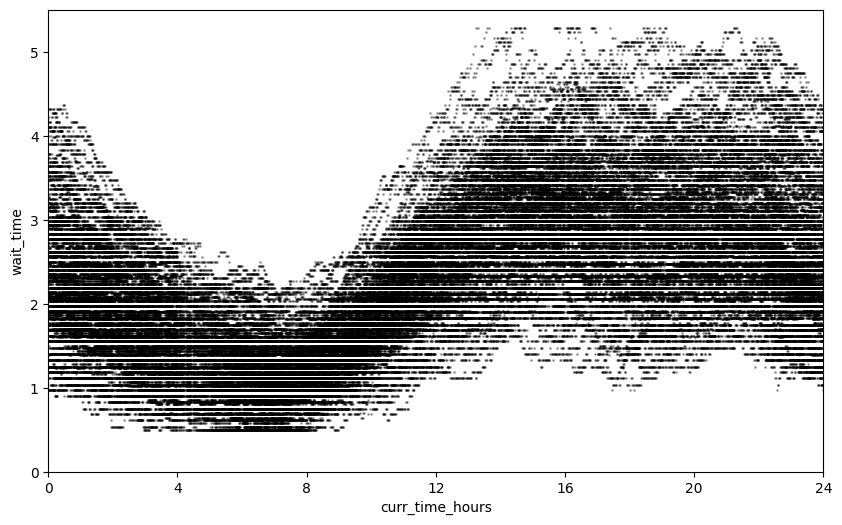

In [8]:
df_train.plot(kind='scatter', x='curr_time_hours', y='wait_time', s=1, c='black', alpha=0.3)
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.xlim(0, 24)
plt.ylim(0, 5.5)
plt.show()

We can see some trimming going on, namely wait time is trimmed below 0.5 and above 5.28 hours.

We also see some rounding in wait_time leading to the horizontal bands - likely something to do with the fact it can only be 60 different values in a given hour.

Apart from this, the data looks as it should, and is ready to create the base heuristic.

## Base heuristic - non-overlapping time bins with simple average

We will bin the training set into 24 bins (one for each hour in the day) and the heuristic's prediction will be the average of all wait times in that hour bin (for a given ED and day of the week).



In [9]:
bin_size_hours = 1.0

In [10]:
# Function to remove outliers from each wait_time group.
# Removes outliers more than +-2stdev from mean
def remove_outliers_zscore(group, threshold=2):
    original_size = len(group)
    z_scores = np.abs(stats.zscore(group['wait_time']))
    filtered_group = group[z_scores < threshold]
    outliers_removed = original_size - len(filtered_group)
    #print(f"Removed {outliers_removed} outliers from group")
    return filtered_group

bin_edges = list(np.arange(0,24.1,bin_size_hours))
df_train['x_bins'] = pd.cut(df_train['curr_time_hours'], bins=bin_edges, right=False)  # Conduct the binning
smooth_curves = df_train.groupby(['x_bins', 'id', 'day_of_week'],group_keys=False).apply(remove_outliers_zscore).reset_index().groupby(['x_bins', 'id', 'day_of_week'])['wait_time'].mean().reset_index()
smooth_curves['x_mid'] = smooth_curves['x_bins'].apply(lambda x: (x.left + x.right) / 2) # Record midpoints of bins to assist plotting
smooth_curves = smooth_curves.rename(columns={'wait_time':'mean_wait_time'})
smooth_curves.tail()

<ipython-input-10-6f4442e0502c>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smooth_curves = df_train.groupby(['x_bins', 'id', 'day_of_week'],group_keys=False).apply(remove_outliers_zscore).reset_index().groupby(['x_bins', 'id', 'day_of_week'])['wait_time'].mean().reset_index()
<ipython-input-10-6f4442e0502c>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  smooth_curves = df_train.groupby(['x_bins', 'id', 'day_of_week'],group_keys=False).apply(remove_outliers_zscore).reset_index().groupby(['x_bins', '

,x_bins,id,day_of_week,mean_wait_time,x_mid
331,"[23.0, 24.0)",NORHOSED,Saturday,1.499614,23.5
332,"[23.0, 24.0)",NORHOSED,Sunday,1.671367,23.5
333,"[23.0, 24.0)",NORHOSED,Thursday,2.127761,23.5
334,"[23.0, 24.0)",NORHOSED,Tuesday,2.082264,23.5
335,"[23.0, 24.0)",NORHOSED,Wednesday,2.135664,23.5


Plot of each of the curves for each ED

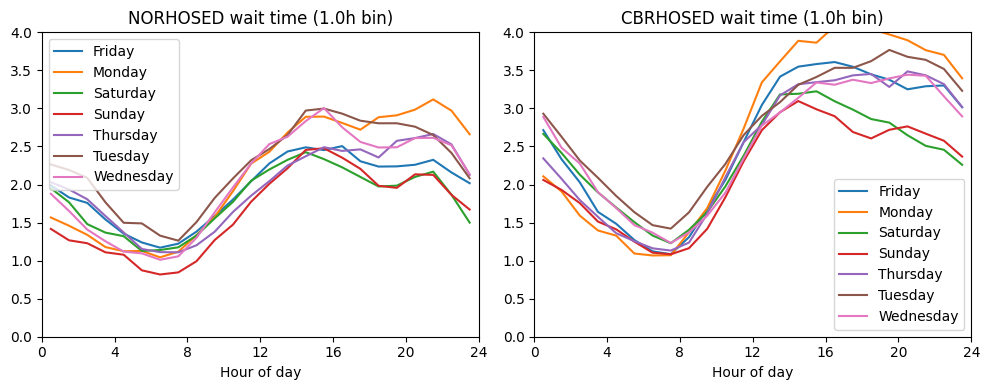

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

grouped = smooth_curves[smooth_curves['id']=='NORHOSED'].groupby(['day_of_week'])
for name, group in grouped:
    ax1.plot(group['x_mid'], group['mean_wait_time'], label=name)

grouped = smooth_curves[smooth_curves['id']=='CBRHOSED'].groupby(['day_of_week'])
for name, group in grouped:
    ax2.plot(group['x_mid'], group['mean_wait_time'], label=name)

ax1.set_xticks([0, 4, 8, 12, 16, 20, 24])
ax1.set_xlim(0, 24)
ax1.set_ylim(0, 4)
ax1.legend()
ax1.set_title(f'NORHOSED wait time ({bin_size_hours}h bin)')
ax1.set_xlabel('Hour of day')

ax2.set_xticks([0, 4, 8, 12, 16, 20, 24])
ax2.set_xlim(0, 24)
ax2.set_ylim(0, 4)
ax2.legend()
ax2.set_title(f'CBRHOSED wait time ({bin_size_hours}h bin)')
ax2.set_xlabel('Hour of day')

plt.tight_layout()
plt.show()

We now have wait time averages for each hour of the day (bin size = 1h). We will create a function that returns the average wait time given the emergency department, time of day, and day of week

In [12]:
wait_time_dict = smooth_curves.set_index(['x_bins', 'id', 'day_of_week'])['mean_wait_time'].to_dict()

def get_bin_interval_fast(hour_of_day, bin_edges, bin_size_hours):
    """
    Quickly find the bin interval for a single value with evenly spaced bins.

    Args:
        hour_of_day: float, the value to bin
        bin_edges: list or array of bin edges (e.g., [0, 1, 2, ..., 24])
        bin_size_hours: float, the width of each bin

    Returns:
        pd.Interval: interval containing hour_of_day, or None if out of bounds
    """
    # Check bounds
    if hour_of_day < bin_edges[0] or hour_of_day >= bin_edges[-1]:
        return None

    # Calculate bin index directly (for [a, b) intervals)
    bin_idx = int(hour_of_day // bin_size_hours)

    # Get left and right edges
    left_edge = bin_edges[bin_idx]
    # Handle potential floating-point issues near the last edge
    right_edge = bin_edges[bin_idx + 1] if bin_idx + 1 < len(bin_edges) else bin_edges[-1]

    return pd.Interval(left_edge, right_edge, closed='left')

def predict_wait_dict(lastUpdated,id,wait_time,hour_of_day,day_of_week,queue):
    lookup_bin = get_bin_interval_fast(hour_of_day, bin_edges, bin_size_hours)
    #lookup_bin = pd.cut([hour_of_day], bins=bin_edges, right=False)[0] # Figure out which bin hour_of_day should be in
    return wait_time_dict.get((lookup_bin, id, day_of_week), None)

predict_wait_dict('dummy','CBRHOSED',-1,22.43,'Monday',14)

3.7035050071530757

## Base heuristic - spline interpolation of binned averages

We will now use spline interpolation to make this average wait time curve smoother - instead of 24 jagged steps, we should get a very smooth curve.

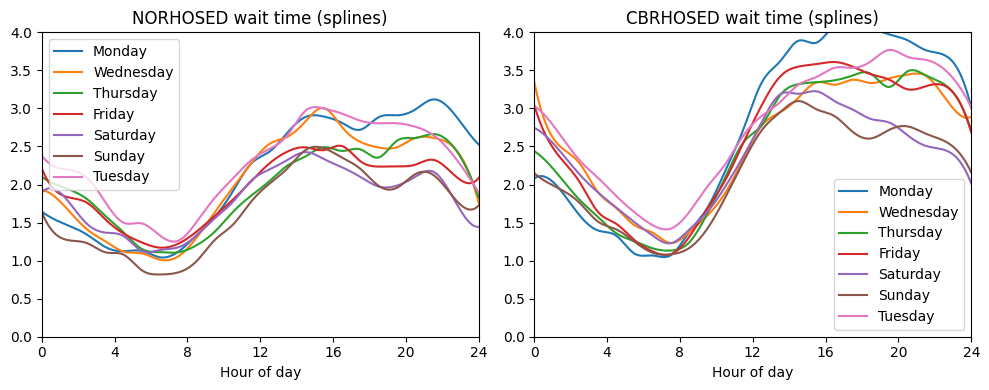

In [13]:
# Interpolates num_splines points given a dataframe with x_mid / mean_wait_time pairs
def interpolate_group(group):
    return make_interp_spline(group['x_mid'], group['mean_wait_time'], k=3)

splines_dict = {}

grouped = smooth_curves.groupby(['id', 'day_of_week'])
for (id_val, day_of_week), group in grouped:
    splines_dict[(id_val, day_of_week)] = interpolate_group(group)

# Group by ID in subplots
x_values = np.linspace(0, 24, 24*60)  # 100 points between 0 and 24

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for _day in list(set(smooth_curves['day_of_week'])):
    ax1.plot(x_values, splines_dict[('NORHOSED',_day)](x_values), label=_day)

for _day in list(set(smooth_curves['day_of_week'])):
    ax2.plot(x_values, splines_dict[('CBRHOSED',_day)](x_values), label=_day)

ax1.set_xticks([0, 4, 8, 12, 16, 20, 24])
ax1.set_xlim(0, 24)
ax1.set_ylim(0, 4)
ax1.legend()
ax1.set_title(f'NORHOSED wait time (splines)')
ax1.set_xlabel('Hour of day')

ax2.set_xticks([0, 4, 8, 12, 16, 20, 24])
ax2.set_xlim(0, 24)
ax2.set_ylim(0, 4)
ax2.legend()
ax2.set_title(f'CBRHOSED wait time (splines)')
ax2.set_xlabel('Hour of day')

plt.tight_layout()
plt.show()

Create the heuristic function for the interpolated average.

In [14]:
def predict_wait_spline(lastUpdated,id,wait_time,lookup_hour,day_of_week, queue):
    return splines_dict[(id,day_of_week)](lookup_hour)
print(predict_wait_spline('dummy','CBRHOSED',-1,22.43,'Monday', 14))

3.710676642763741


## Base heuristic - time-queue bin averages

This heuristic calculates the average wait time for every combination of (ED, day of week, time of day, queue size). If a certain combination doesn't exist in the training data, the heuristic will predict based on the average wait time for the (ED, day of week, time of day) combination with the closest queue time (e.g., if CBRHOSED, Monday, 20:00, 14 in queue doesn't have any observations, it'll use the mean from CBRHOSED, Monday, 20:00, 16 in queue if those observations exist).

Because this heuristic uses queue time (which is correlated to wait time), it should provide improved prediction metrics compared to the simple time-based spline interpolation heuristic.

First we will visualise what the mean wait time looks like for every (ID, day, hour, queue) combination

In [15]:
import seaborn as sns
from matplotlib.colors import ListedColormap

def create_heatmap_tables(df, statistic='count'):
    """
    Create heatmap tables for each ED id showing queue counts across time and queue sizes.

    Args:
        df: DataFrame with columns: id, curr_time_hours, day_of_week, queue, wait_time

    Returns:
        None (displays plots)
    """
    # Ensure day_of_week is in ordered categorical form
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

    # Bin curr_time_hours into hourly segments (0-23)
    df['time_bin'] = pd.cut(df['curr_time_hours'],
                           bins=np.arange(0, 24.1, 1),
                           right=False,
                           labels=[f'{i:02d}' for i in range(24)])

    # Create a combined time column for the x-axis (day + hour)
    df['time_segment'] = df['day_of_week'].astype(str) + ' ' + df['time_bin'].astype(str)

    # Get unique IDs
    unique_ids = df['id'].unique()

    # Get all possible queue values
    queue_range = range(int(df['queue'].min()), int(df['queue'].max()) + 1)

    # Create a full set of time segments (7 days * 24 hours)
    all_time_segments = [f"{day} {hour:02d}"
                        for day in day_order
                        for hour in range(24)]

    # Process each ID
    for ed_id in unique_ids:
        # Filter data for this ID
        id_df = df[df['id'] == ed_id]

        # Create pivot table: count occurrences for each time_segment and queue
        pivot = pd.pivot_table(id_df,
                             index='queue',
                             columns='time_segment',
                             values='wait_time',  # Any column will do since we just want counts
                             aggfunc=statistic,
                             fill_value=0)

        # Reindex to include all queue values and time segments
        pivot = pivot.reindex(index=list(reversed(queue_range)),
                      columns=all_time_segments,
                      fill_value=0)

        # Create custom colormap: grey for 0, then YlOrRd for positive counts
        base_cmap = plt.get_cmap('YlOrRd', 256)  # Get base colormap
        colors = [(0.7, 0.7, 0.7)]  # Grey for 0
        colors.extend(base_cmap(np.linspace(0, 1, 255)))  # Rest of YlOrRd
        custom_cmap = ListedColormap(colors)

        # Create heatmap
        plt.figure(figsize=(20, 10))
        sns.heatmap(pivot,
                   cmap=custom_cmap,
                   annot=False,  # Set True if you want counts shown
                   fmt='d',
                   cbar_kws={'label': statistic})

        # Customize plot
        plt.title(f'Queue Distribution Heatmap for ED: {ed_id}', pad=20)
        plt.xlabel('Day and Hour of Week')
        plt.ylabel('Queue Size')

        # Rotate x-axis labels for readability
        plt.xticks(rotation=90, ha='right')

        # Adjust layout to prevent label cutoff
        plt.tight_layout()

        # Show plot
        plt.show()

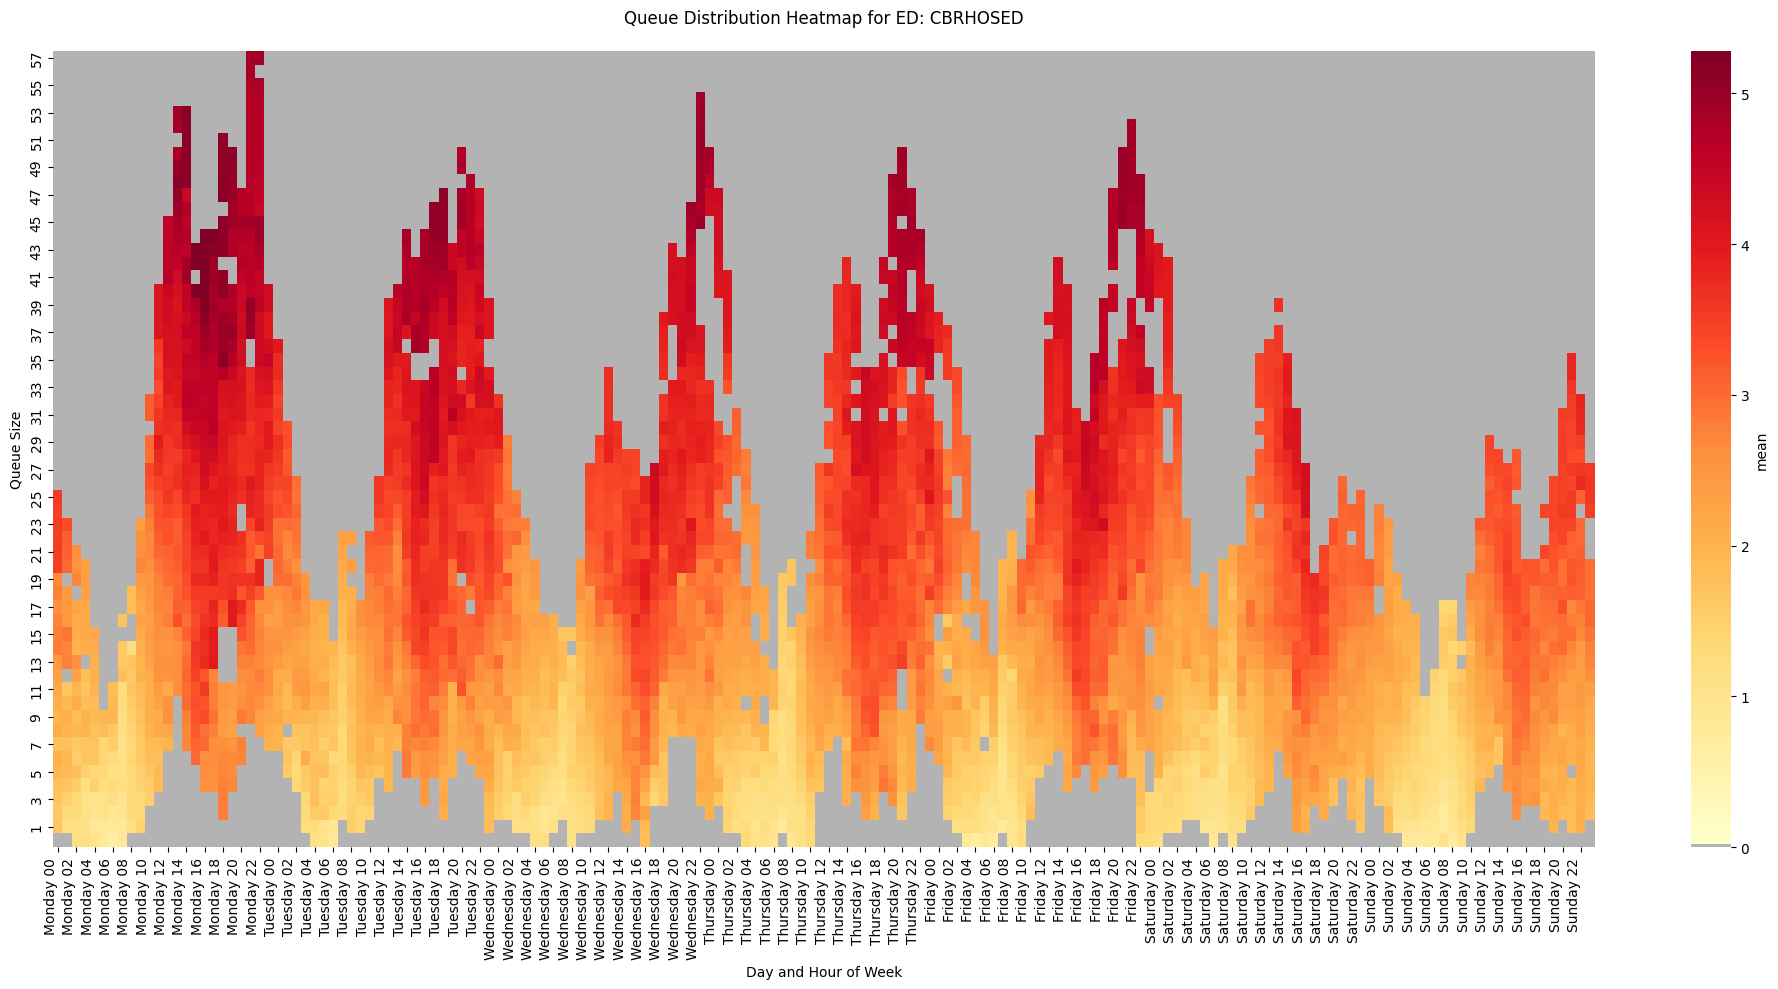

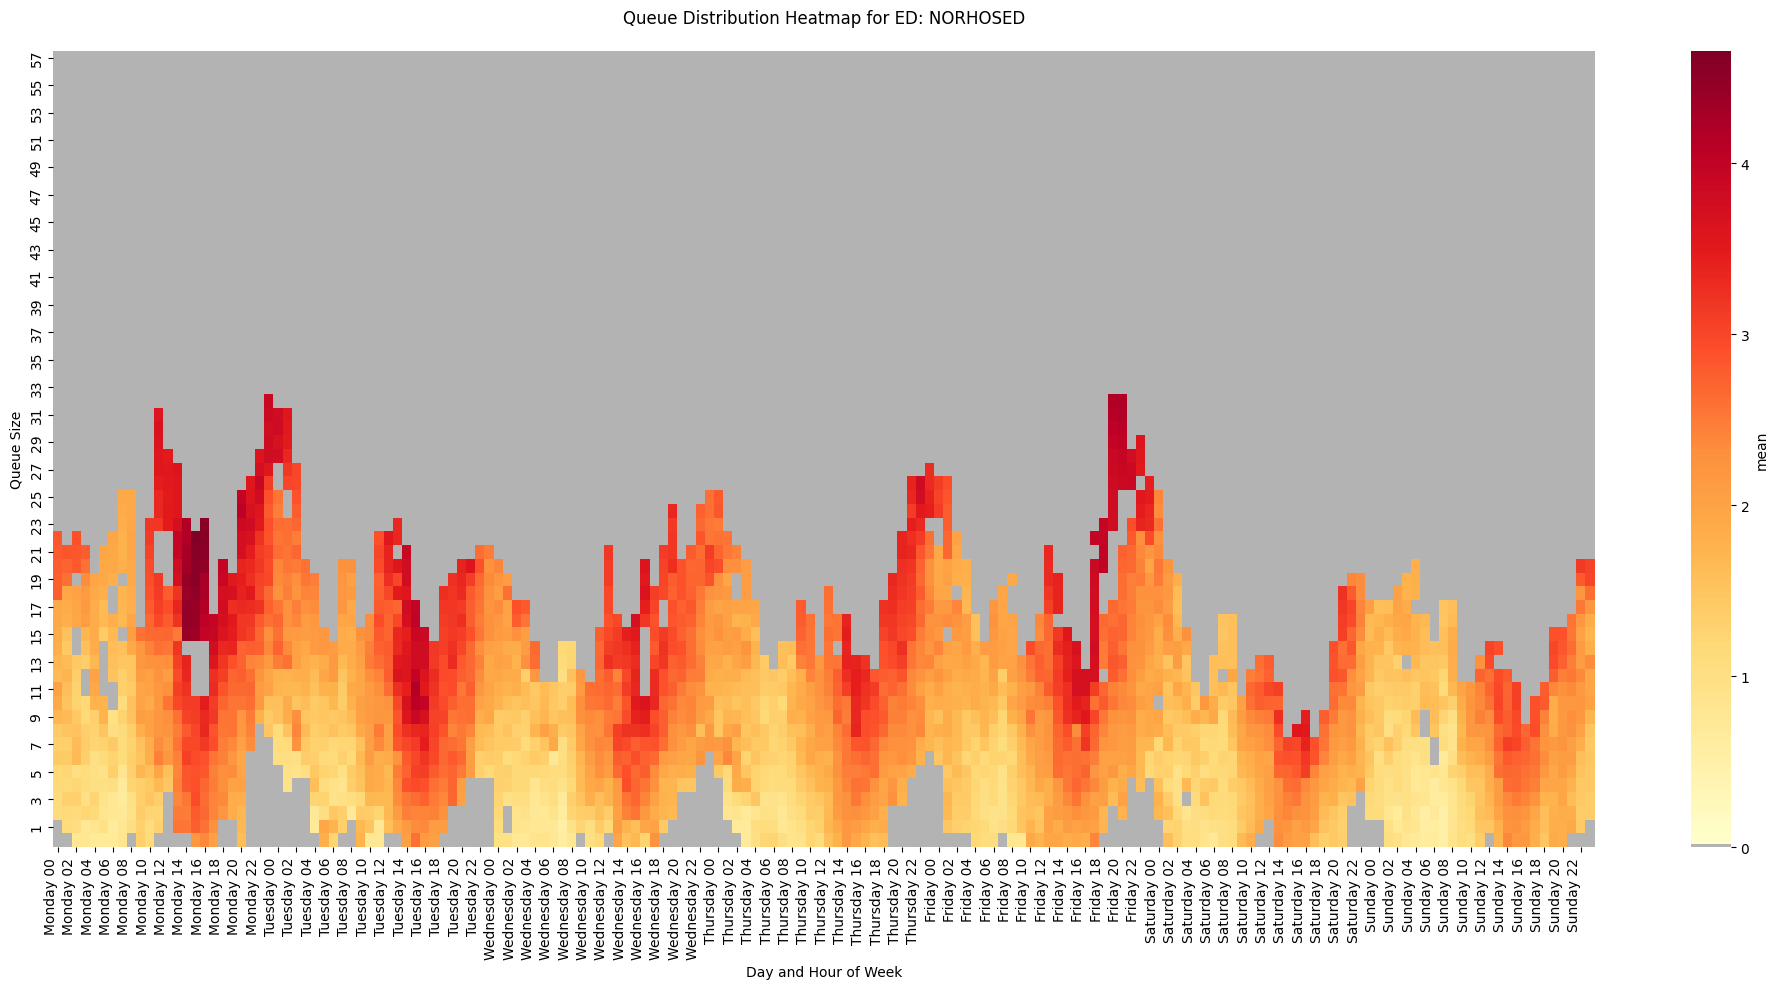

In [16]:
create_heatmap_tables(df_train, 'mean')

Now we will create the dictionary that maps (ID, day, hour, queue) combinations to mean wait_time (or the mean wait_time for the closest queue size that exists).

In [17]:
def create_wait_time_dict_closestqueue(df):
    """
    Create a dictionary with mean wait times for each id, day, hour, and queue combo.
    If no observations exist for a specific queue combo, use the mean wait_time from the closest queue size.

    Args:
        df: DataFrame with columns: id, curr_time_hours, day_of_week, queue, wait_time

    Returns:
        dict: Keys are (id, day_of_week, hour_of_week, queue_size), values are mean wait_time
    """
    # Ensure day_of_week is in ordered categorical form for consistency
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

    # Bin curr_time_hours into hourly segments (0-23)
    df['time_bin'] = pd.cut(df['curr_time_hours'],
                           bins=np.arange(0, 24.1, 1),
                           right=False,
                           labels=[f'{i:02d}' for i in range(24)])

    # Convert time_bin to string for concatenation
    df['time_segment'] = df['day_of_week'].astype(str) + ' ' + df['time_bin'].astype(str)

    # Get unique IDs
    unique_ids = df['id'].unique()

    # Create a full set of time segments (7 days * 24 hours)
    all_time_segments = [f"{day} {hour:02d}"
                        for day in day_order
                        for hour in range(24)]

    # Initialize the result dictionary
    wait_time_dict = {}

    # Process each ID
    for ed_id in unique_ids:
        # Filter data for this ID
        id_df = df[df['id'] == ed_id]

        # Create pivot table with mean wait_time for specific queue combos
        pivot_specific = pd.pivot_table(id_df,
                                       index='queue',
                                       columns='time_segment',
                                       values='wait_time',
                                       aggfunc='mean')

        # Reindex pivot to include all time segments
        pivot_specific = pivot_specific.reindex(columns=all_time_segments)

        # Get all possible queue sizes from the data
        queue_range = range(int(df['queue'].min()), int(df['queue'].max()) + 1)

        # Reindex specific pivot to include all queue sizes (leave NaN for missing)
        pivot_specific = pivot_specific.reindex(index=queue_range)

        # Fill dictionary
        for queue_size in queue_range:
            for time_segment in all_time_segments:
                # Split time_segment into day and hour
                day_of_week, hour_of_week = time_segment.split(' ')

                # Get specific mean wait time for this queue combo
                specific_mean = (pivot_specific.loc[queue_size, time_segment]
                               if queue_size in pivot_specific.index and not pd.isna(pivot_specific.loc[queue_size, time_segment])
                               else np.nan)

                # If specific mean is NaN (no observations), find the closest queue size with data
                if pd.isna(specific_mean):
                    # Get the column (time_segment) from pivot_specific
                    time_segment_series = pivot_specific[time_segment]

                    # Filter out NaN values and get available queue sizes
                    available_queues = time_segment_series.dropna().index

                    if not available_queues.empty:
                        # Find the closest queue size
                        closest_queue = available_queues[np.argmin(np.abs(available_queues - queue_size))]
                        mean_wait_time = pivot_specific.loc[closest_queue, time_segment]
                    else:
                        # If no queue sizes have data for this time segment, use 0
                        mean_wait_time = 0
                else:
                    mean_wait_time = specific_mean

                # Create the key tuple and assign value
                key = (ed_id, day_of_week, hour_of_week, queue_size)
                wait_time_dict[key] = mean_wait_time

    return wait_time_dict

In [18]:
wait_time_dict_queuetimemean_closestqueue = create_wait_time_dict_closestqueue(df_train)
wait_time_dict_queuetimemean_closestqueue[('CBRHOSED', 'Monday', '22', 14)]

2.719607843137255

Now create the heuristic function that wraps this dictionary.

In [19]:
def predict_wait_queuetime_closestqueue(lastUpdated,id,wait_time,lookup_hour,day_of_week, queue):
    return wait_time_dict_queuetimemean_closestqueue[(id,day_of_week, str(int(lookup_hour)).zfill(2), queue)]
print(predict_wait_queuetime_closestqueue('dummy','CBRHOSED','dummy','22','Monday',14))

2.719607843137255


## Evaluate heuristic performance

We can now compare all 3 heuristics on the same testing set (~1 month of data that occurs after the training data, and was unseen during heuristic creation).

In [20]:
def evaluate_predictor(df, predictor_func, input_columns, actual_column):
    # Apply the predictor function to the specified input columns
    predictions = df.apply(lambda row: predictor_func(*row), axis=1)

    # Get the actual values
    actuals = df[actual_column]
    df = df.assign(pred_wait_time=predictions)
    errors = predictions-actuals

    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals))
    r2 = r2_score(actuals, predictions)

    # Print results
    print(f"RMSE: {round(rmse,4)}")
    print(f"MSE : {round(mse,4)}")
    print(f"MAE : {round(mae,4)}")
    print(f"MAPE: {round(mape,4)}")
    print(f"R²  : {round(r2,4)}")

    return df, errors, rmse, mse, mae, mape, r2

print('Test size:', len(df_test))

print('\nEvaluating bins average')
bins_predictions, bins_errors, bins_rmse, bins_mse, bins_mae, bins_mape, bins_r2 = evaluate_predictor(df_test, predict_wait_dict, ['id','day_of_week','curr_time_hours'],'wait_time')

print('\nEvaluating spline function')
spline_predictions, spline_errors, spline_rmse, spline_mse, spline_mae, spline_mape, spline_r2 = evaluate_predictor(df_test, predict_wait_spline, ['id','day_of_week','curr_time_hours'],'wait_time')

print('\nEvaluating queutime closestqueue average')
qt_cq_predictions, qt_cq_errors, qt_cq_rmse, qt_cq_mse, qt_cq_mae, qt_cq_mape, qt_cq_r2 = evaluate_predictor(df_test, predict_wait_queuetime_closestqueue, ['id','day_of_week','curr_time_hours'],'wait_time')

Test size: 59785

Evaluating bins average
RMSE: 0.5652
MSE : 0.3195
MAE : 0.4381
MAPE: 0.1966
R²  : 0.6674

Evaluating spline function
RMSE: 0.5621
MSE : 0.316
MAE : 0.4356
MAPE: 0.1953
R²  : 0.671

Evaluating queutime closestqueue average
RMSE: 0.3966
MSE : 0.1573
MAE : 0.3159
MAPE: 0.1476
R²  : 0.8362


Plot the predictions for both heuristic functions used.

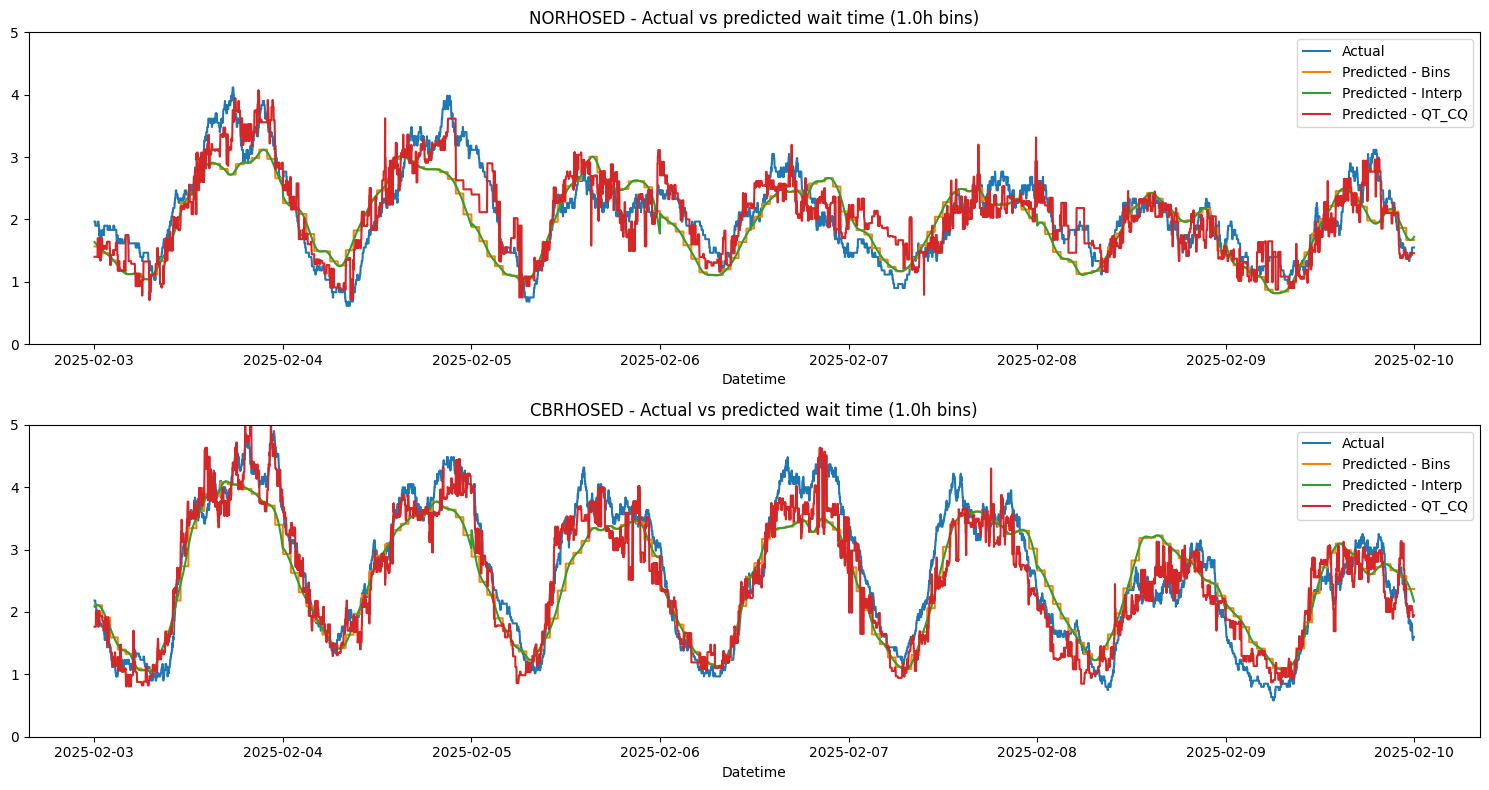

In [21]:
start_date = '2025-02-03'
end_date = '2025-02-10'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))


norhosed_df = bins_predictions[(bins_predictions['id']=='NORHOSED') & (bins_predictions['lastUpdated'] >= start_date) & (bins_predictions['lastUpdated'] <= end_date)]
ax1.plot(norhosed_df['lastUpdated'],norhosed_df['wait_time'],label='Actual')
ax1.plot(norhosed_df['lastUpdated'],norhosed_df['pred_wait_time'],label='Predicted - Bins')
norhosed_df = spline_predictions[(spline_predictions['id']=='NORHOSED') & (spline_predictions['lastUpdated'] >= start_date) & (spline_predictions['lastUpdated'] <= end_date)]
ax1.plot(norhosed_df['lastUpdated'],norhosed_df['pred_wait_time'],label='Predicted - Spline')
norhosed_df = qt_cq_predictions[(qt_cq_predictions['id']=='NORHOSED') & (qt_cq_predictions['lastUpdated'] >= start_date) & (qt_cq_predictions['lastUpdated'] <= end_date)]
ax1.plot(norhosed_df['lastUpdated'],norhosed_df['pred_wait_time'],label='Predicted - QT_CQ')


cbrhosed_df = bins_predictions[(bins_predictions['id']=='CBRHOSED') & (bins_predictions['lastUpdated'] >= start_date) & (bins_predictions['lastUpdated'] <= end_date)]
ax2.plot(cbrhosed_df['lastUpdated'],cbrhosed_df['wait_time'],label='Actual')
ax2.plot(cbrhosed_df['lastUpdated'],cbrhosed_df['pred_wait_time'],label='Predicted - Bins')
cbrhosed_df = spline_predictions[(spline_predictions['id']=='CBRHOSED') & (spline_predictions['lastUpdated'] >= start_date) & (spline_predictions['lastUpdated'] <= end_date)]
ax2.plot(cbrhosed_df['lastUpdated'],cbrhosed_df['pred_wait_time'],label='Predicted - Spline')
cbrhosed_df = qt_cq_predictions[(qt_cq_predictions['id']=='CBRHOSED') & (qt_cq_predictions['lastUpdated'] >= start_date) & (qt_cq_predictions['lastUpdated'] <= end_date)]
ax2.plot(cbrhosed_df['lastUpdated'],cbrhosed_df['pred_wait_time'],label='Predicted - QT_CQ')


ax1.legend()
ax1.set_ylim(0, 5)
ax1.set_title(f'NORHOSED - Actual vs predicted wait time ({bin_size_hours}h bins)')
ax1.set_xlabel('Datetime')
ax2.legend()
ax2.set_ylim(0, 5)
ax2.set_title(f'CBRHOSED - Actual vs predicted wait time ({bin_size_hours}h bins)')
ax2.set_xlabel('Datetime')
plt.tight_layout()
plt.show()

Plot the distribution of errors (in hours)

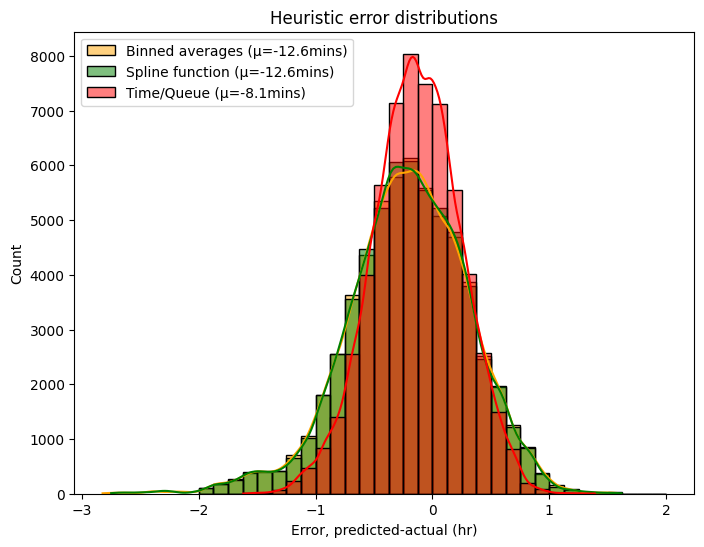

In [22]:
error_hrs_limit = 2
hist_bins = np.linspace(-1*error_hrs_limit,error_hrs_limit,num=2**5+1)
plt.figure(figsize=(8, 6))
sns.histplot(data=list(bins_errors), bins=hist_bins, kde=True, color='orange', edgecolor='black',label='Binned averages (μ='+str(round(np.mean(bins_errors)*60,1))+'mins)')
sns.histplot(data=list(spline_errors), bins=hist_bins, kde=True, color='green', edgecolor='black',label='Spline function (μ='+str(round(np.mean(spline_errors)*60,1))+'mins)')
sns.histplot(data=list(qt_cq_errors), bins=hist_bins, kde=True, color='red', edgecolor='black',label='Time/Queue (μ='+str(round(np.mean(qt_cq_errors)*60,1))+'mins)')
plt.title('Heuristic error distributions')
plt.xlabel('Error, predicted-actual (hr)')
plt.legend()
plt.show()

We can see that

*   The Time/Queue (closest queue) heuristic has a tighter error distribution than the other two heuristics, leading to better error metrics.
*   All three heuristics appear to, on average, underestimate the wait time (median and mean error for all three are < 0 hrs)

We now have a decent baseline heuristic that we can compare any machine learning models with. To be valuable, the ML model error metrics should be statistically significantly better than the 'dumb' Time/Queue baseline heuristic error metrics.
